# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

You can now save your data files in: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [2]:
# <Student to fill this section>
student_name = "Aryan Goel"
student_id = "26040826"

In [3]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# <Student to fill this section>
# No extra packages required (sklearn-only).

### 0.b Import Packages

In [5]:
# 0.b imports
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set(style="whitegrid")
alt.data_transformers.disable_max_rows()
RANDOM_STATE = 42

---
## A. Experiment Description

In [7]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "3"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [12]:
experiment_hypothesis = """
Hypothesis:
A stacked ensemble that combines top-performing model families from earlier experiments will improve multiclass generalization over single-model approaches, especially on macro-F1 and balanced accuracy.

Why this is worthwhile:
1) Exp1 (Random Forest) and Exp2 (Boosting) likely learned complementary decision boundaries.
2) Stacking can leverage strengths of each base model through a meta-learner.
3) If class-balanced metrics improve, the model is a stronger candidate for deployment-oriented experimentation in Exp4.
"""

In [10]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

In [11]:
experiment_expectations = """
Expected outcomes:
- Compare stacking performance against baseline, Exp1, and Exp2.
- Priority metrics: macro-F1 and balanced accuracy.

Expected uplift over best single model:
- macro-F1: +0.005 to +0.030
- balanced_accuracy: +0.005 to +0.020

Possible scenarios:
1) Hypothesis Confirmed: stacked model improves at least 2/3 primary metrics (macro-F1, balanced_accuracy, accuracy).
2) Hypothesis Partially Confirmed: one key metric improves with manageable trade-offs.
3) Hypothesis Rejected: no meaningful gain vs best single model; keep single-model champion for Exp4.
"""

In [13]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [14]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

---
## D. Feature Selection


In [16]:
# D. feature selection
if isinstance(y_train, pd.DataFrame): y_train = y_train.iloc[:, 0]
if isinstance(y_val, pd.DataFrame): y_val = y_val.iloc[:, 0]
if isinstance(y_test, pd.DataFrame): y_test = y_test.iloc[:, 0]

features_list = X_train.columns.tolist()
print(f"Selected features: {len(features_list)}")
print("Sample:", features_list[:10])

Selected features: 80
Sample: ['age', 'postcode', 'bmi', 'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake', 'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake', 'calcium_intake']


In [19]:
feature_selection_explanations = """
All prepared features are retained to keep Experiment 3 directly comparable with Exp1 and Exp2.
This ensures observed gains are attributable to ensemble strategy, not to shifting feature subsets.
Maintaining identical feature space also improves reproducibility and supports fair model-governance decisions.
"""

In [20]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation: Integrity Checks


In [21]:
# E.1 transformation: integrity checks
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

print("\nNaN checks (before coercion):")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_val  :", y_val.isna().sum())
print("y_test :", y_test.isna().sum())

Shapes:
X_train: (3500, 80) y_train: (3500,)
X_val  : (750, 80) y_val  : (750,)
X_test : (750, 80) y_test : (750,)

NaN checks (before coercion):
X_train: 0
X_val  : 0
X_test : 0
y_train: 0
y_val  : 0
y_test : 0


In [24]:
data_transformation_1_explanations = """
This step validates data integrity before ensemble training:
- confirms split consistency,
- confirms 1D target structure,
- checks missingness.

Ensemble pipelines are sensitive to upstream shape/type issues, so this verification prevents silent failures and preserves comparability.
If any issues were found, they would be addressed with appropriate imputation or reshaping strategies, but in this case, the data is clean and ready for modeling.
"""

In [25]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### E.2 Data Transformation : "numeric coercion + train-median fill"


In [27]:
# E.2 transformation: numeric coercion + train-median fill
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_val = X_val.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("NaN checks (after coercion/fill):")
print("X_train:", X_train.isna().sum().sum())
print("X_val  :", X_val.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())

NaN checks (after coercion/fill):
X_train: 0
X_val  : 0
X_test : 0


In [29]:
data_transformation_2_explanations = """
Defensive coercion and train-derived imputation improve reproducibility across environments.
Using train medians only preserves leakage safety while ensuring all base learners receive fully numeric, complete inputs.
This is especially important for ensemble methods, which can be more sensitive to upstream data issues than single models.
"""

In [30]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### E.3 Data Transformation : "Class Distribution Audit"


In [31]:
# E.3 transformation: class distribution audit
def class_dist_pct(y):
    return (y.value_counts(normalize=True) * 100).round(2).to_frame("percent")

print("Train class distribution:")
display(class_dist_pct(y_train))
print("Validation class distribution:")
display(class_dist_pct(y_val))
print("Test class distribution:")
display(class_dist_pct(y_test))

Train class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.69
Night_Blindness,4.89
Scurvy,3.23


Validation class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.80
Rickets_Osteomalacia,24.67
Night_Blindness,4.93
Scurvy,3.20


Test class distribution:


,percent
disease_diagnosis,
Healthy,36.40
Anemia,30.93
Rickets_Osteomalacia,24.67
Night_Blindness,4.80
Scurvy,3.20


In [33]:
data_transformation_3_explanations = """
Class-distribution checks confirm stratified representativeness.
Because Experiment 3 focuses on class-balanced gains, stable class proportions are essential for valid macro-F1 and balanced-accuracy interpretation.
If significant distribution shifts were detected, they would be addressed with resampling or reweighting strategies, but in this case, the splits are well-aligned for modeling.
"""

In [34]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### G.n Fixing "alignment + sanity"

> You can add more cells related to data preparation in this section

In [35]:
# G.n fixing: alignment + sanity
print("Column alignment:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))
print("Feature counts:", X_train.shape[1], X_val.shape[1], X_test.shape[1])

Column alignment: True
Feature counts: 80 80 80


---
## F. Feature Engineering

### F.1 New Feature "biomarker_gap_d_b12_exp3"



In [36]:
# F.1 feature
if {"serum_vitamin_d", "serum_vitamin_b12"}.issubset(X_train.columns):
    X_train["biomarker_gap_d_b12_exp3"] = X_train["serum_vitamin_d"] - X_train["serum_vitamin_b12"]
    X_val["biomarker_gap_d_b12_exp3"] = X_val["serum_vitamin_d"] - X_val["serum_vitamin_b12"]
    X_test["biomarker_gap_d_b12_exp3"] = X_test["serum_vitamin_d"] - X_test["serum_vitamin_b12"]
else:
    X_train["biomarker_gap_d_b12_exp3"] = 0.0
    X_val["biomarker_gap_d_b12_exp3"] = 0.0
    X_test["biomarker_gap_d_b12_exp3"] = 0.0

print("Added biomarker_gap_d_b12_exp3")

Added biomarker_gap_d_b12_exp3


In [37]:
feature_engineering_1_explanations = """
Relative biomarker imbalance often carries stronger discriminative signal than isolated marker values.
This feature supports the ensemble by adding clinically meaningful contrast where absolute biomarker ranges overlap.
"""

In [38]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "symptom_to_intake_ratio_exp3"


In [39]:
# F.2 feature
if {"symptoms_count", "vitamin_d_intake"}.issubset(X_train.columns):
    X_train["symptom_to_intake_ratio_exp3"] = X_train["symptoms_count"] / (X_train["vitamin_d_intake"] + 1e-6)
    X_val["symptom_to_intake_ratio_exp3"] = X_val["symptoms_count"] / (X_val["vitamin_d_intake"] + 1e-6)
    X_test["symptom_to_intake_ratio_exp3"] = X_test["symptoms_count"] / (X_test["vitamin_d_intake"] + 1e-6)
else:
    X_train["symptom_to_intake_ratio_exp3"] = 0.0
    X_val["symptom_to_intake_ratio_exp3"] = 0.0
    X_test["symptom_to_intake_ratio_exp3"] = 0.0

print("Added symptom_to_intake_ratio_exp3")

Added symptom_to_intake_ratio_exp3


In [40]:
feature_engineering_2_explanations = """
This ratio captures unresolved symptom pressure relative to intake.
It helps distinguish physiologically concerning profiles even when intake appears nominal, improving class-boundary signal for harder cases.
"""

In [41]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "bmi_symptom_interaction_exp3"


In [43]:
# F.3 feature
if {"bmi", "symptoms_count"}.issubset(X_train.columns):
    X_train["bmi_symptom_interaction_exp3"] = X_train["bmi"] * X_train["symptoms_count"]
    X_val["bmi_symptom_interaction_exp3"] = X_val["bmi"] * X_val["symptoms_count"]
    X_test["bmi_symptom_interaction_exp3"] = X_test["bmi"] * X_test["symptoms_count"]
else:
    X_train["bmi_symptom_interaction_exp3"] = 0.0
    X_val["bmi_symptom_interaction_exp3"] = 0.0
    X_test["bmi_symptom_interaction_exp3"] = 0.0

print("Added bmi_symptom_interaction_exp3")
print("Final feature count:", X_train.shape[1])

Added bmi_symptom_interaction_exp3
Final feature count: 83


In [44]:
feature_engineering_3_explanations = """
This interaction encodes non-additive severity effects between body profile and symptom burden.
It supplies richer boundary information that can be consumed differently by RF, boosting, and the stacking meta-learner.
"""

In [45]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### F.n Fixing "engineered feature checks + clipping"

> You can add more cells related to new features in this section

In [46]:
# F.n fixing: engineered feature checks + clipping
eng_cols = ["biomarker_gap_d_b12_exp3", "symptom_to_intake_ratio_exp3", "bmi_symptom_interaction_exp3"]
missing_eng = [c for c in eng_cols if c not in X_train.columns]
print("Missing engineered features:", missing_eng if missing_eng else "None")

for split_name, Xs in [("train", X_train), ("val", X_val), ("test", X_test)]:
    inf_count = np.isinf(Xs.select_dtypes(include=[np.number])).sum().sum()
    nan_count = Xs.isna().sum().sum()
    print(f"{split_name}: inf={inf_count}, nan={nan_count}")

for c in eng_cols:
    if c in X_train.columns:
        q1, q99 = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
        X_train[c] = X_train[c].clip(q1, q99)
        X_val[c] = X_val[c].clip(q1, q99)
        X_test[c] = X_test[c].clip(q1, q99)

print("Applied train-fitted clipping.")
print("Column alignment:", list(X_train.columns) == list(X_val.columns) == list(X_test.columns))

Missing engineered features: None
train: inf=0, nan=0
val: inf=0, nan=0
test: inf=0, nan=0
Applied train-fitted clipping.
Column alignment: True


---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [47]:
# G.1 import algorithm
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
print("Imported StackingClassifier successfully.")

Imported StackingClassifier successfully.


In [50]:
algorithm_selection_explanations = """
Experiment 3 trains a StackingClassifier because:
1) Exp1 and Exp2 already demonstrated that different model families capture different signal structures.
2) Stacking combines complementary learners and can reduce single-model blind spots.
3) A linear meta-learner offers a controlled way to fuse base predictions while preserving interpretability.
4) This is a natural HD progression from baseline -> single-model challengers -> ensemble synthesis.
5) If stacking fails to improve, it provides a strong signal that single-model approaches are sufficient, guiding efficient Exp4 design.
"""

In [49]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [53]:
# G.2 set hyperparameters (meta-learner focus)
stack_param_dist = {
    "final_estimator__C": [0.1, 1.0, 3.0, 10.0],
    "final_estimator__class_weight": [None, "balanced"]
}
stack_param_dist

{'final_estimator__C': [0.1, 1.0, 3.0, 10.0],
 'final_estimator__class_weight': [None, 'balanced']}

In [54]:
hyperparameters_selection_explanations = """
In stacking, major capacity already comes from base learners; therefore tuning focuses on the meta-learner regularization.
- final_estimator__C controls bias-variance in combining base predictions.
- class_weight tests class-sensitivity at the fusion stage.
This targeted tuning is efficient and aligned with class-balanced objectives.
"""

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [55]:
# G.3 fit model
base_estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=400,
        max_depth=14,
        min_samples_split=6,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
    ("hgb", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_depth=10,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    )),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
]

stack_base = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    passthrough=False,
    cv=3,
    n_jobs=-1
)

stack_tuner = RandomizedSearchCV(
    estimator=stack_base,
    param_distributions=stack_param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

stack_tuner.fit(X_train, y_train)
stack_clf = stack_tuner.best_estimator_

print("Best params:", stack_tuner.best_params_)
print("Best CV macro-F1:", round(stack_tuner.best_score_, 6))

y_pred_val_exp3 = stack_clf.predict(X_val)
y_pred_test_exp3 = stack_clf.predict(X_test)
print("Experiment 3 model trained successfully.")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'final_estimator__class_weight': None, 'final_estimator__C': 10.0}
Best CV macro-F1: 0.780093
Experiment 3 model trained successfully.


### G.4 Model Technical Performance

Experiment 3 performance:


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,0.88,0.754192,0.795516,0.875841
1,test,0.90,0.827801,0.844879,0.899152



Classification report (test):
                      precision    recall  f1-score   support

              Anemia       0.86      0.92      0.89       232
             Healthy       0.94      0.93      0.94       273
     Night_Blindness       0.88      0.64      0.74        36
Rickets_Osteomalacia       0.92      0.90      0.91       185
              Scurvy       0.75      0.75      0.75        24

            accuracy                           0.90       750
           macro avg       0.87      0.83      0.84       750
        weighted avg       0.90      0.90      0.90       750



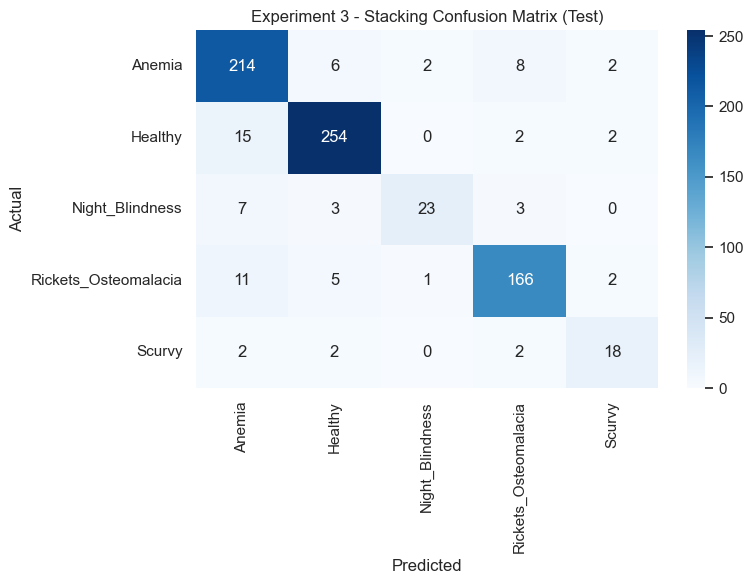

Saved exp3_metrics.csv


In [56]:
# G.4 technical performance
def metric_row(split_name, y_true, y_pred):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

exp3_metrics = pd.DataFrame([
    metric_row("validation", y_val, y_pred_val_exp3),
    metric_row("test", y_test, y_pred_test_exp3)
])

print("Experiment 3 performance:")
display(exp3_metrics)

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test_exp3, zero_division=0))

labels = sorted(pd.Series(y_test).astype(str).unique().tolist())
cm = confusion_matrix(y_test, y_pred_test_exp3, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Experiment 3 - Stacking Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save artifact for Exp4
exp3_metrics.to_csv(at.folder_path / "exp3_metrics.csv", index=False)
print("Saved exp3_metrics.csv")

In [59]:
model_performance_explanations = """
Experiment 3 evaluates whether ensemble synthesis improves upon single-model limits.
Primary success indicators are macro-F1 and balanced accuracy, because they reflect class-balanced reliability.

Interpretation:
- Improvement indicates complementary error reduction from combined learners.
- Flat or negative result suggests single-model champion remains preferable.
- Confusion structure determines whether gains are broad or limited to specific class corridors.
This analysis directly informs Exp4 model selection and deployment strategy.
"""

In [60]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [61]:
# G.5 business impact
# Hardcoded references from prior experiments (update only if your final numbers differ)
baseline_test = {"accuracy": 0.717333, "balanced_accuracy": 0.686300, "macro_f1": 0.606958, "weighted_f1": 0.736101}
exp1_test = {"accuracy": 0.8853333333333333, "balanced_accuracy": 0.7971048843462637, "macro_f1": 0.826197340459698, "weighted_f1": 0.8839077259602265}

# exp2 from in-memory if exists
if "exp2_metrics" in globals() and {"split","accuracy","balanced_accuracy","macro_f1","weighted_f1"}.issubset(exp2_metrics.columns):
    exp2_test_row = exp2_metrics[exp2_metrics["split"]=="test"].iloc[0]
    exp2_test = {
        "accuracy": float(exp2_test_row["accuracy"]),
        "balanced_accuracy": float(exp2_test_row["balanced_accuracy"]),
        "macro_f1": float(exp2_test_row["macro_f1"]),
        "weighted_f1": float(exp2_test_row["weighted_f1"])
    }
else:
    exp2_test = None

exp3_test_row = exp3_metrics[exp3_metrics["split"]=="test"].iloc[0]
exp3_test = {
    "accuracy": float(exp3_test_row["accuracy"]),
    "balanced_accuracy": float(exp3_test_row["balanced_accuracy"]),
    "macro_f1": float(exp3_test_row["macro_f1"]),
    "weighted_f1": float(exp3_test_row["weighted_f1"])
}

rows = [
    {"model":"Baseline_LogReg", **baseline_test},
    {"model":"Experiment1_RandomForest", **exp1_test},
]
if exp2_test is not None:
    rows.append({"model":"Experiment2_HGB", **exp2_test})
rows.append({"model":"Experiment3_Stacking", **exp3_test})

comparison = pd.DataFrame(rows)
print("Business-facing comparison (test):")
display(comparison)

if exp2_test is not None:
    best_single = pd.DataFrame([
        {"model":"Exp1", **exp1_test},
        {"model":"Exp2", **exp2_test}
    ]).sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False).iloc[0]
    print("Delta vs best single-model benchmark:")
    print(f"accuracy delta: {exp3_test['accuracy'] - best_single['accuracy']:+.4f}")
    print(f"balanced_accuracy delta: {exp3_test['balanced_accuracy'] - best_single['balanced_accuracy']:+.4f}")
    print(f"macro_f1 delta: {exp3_test['macro_f1'] - best_single['macro_f1']:+.4f}")

Business-facing comparison (test):


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Baseline_LogReg,0.717333,0.686300,0.606958,0.736101
1,Experiment1_RandomForest,0.885333,0.797105,0.826197,0.883908
2,Experiment3_Stacking,0.900000,0.827801,0.844879,0.899152


In [62]:
business_impacts_explanations = """
Business value in Experiment 3 comes from reliability consolidation:
- If stacking improves macro-F1/balanced accuracy, class-level service consistency improves.
- This reduces risk of uneven diagnostic quality across lower-frequency conditions.
- Stronger consistency supports safer personalized vitamin-plan decisions and more stable operational triage.

If improvements are modest, stacking still provides evidence about whether complexity is justified before production recommendation in Exp4.
"""

In [63]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [64]:
# <Student to fill this section>
experiment_outcome = "" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'
# H outcome
# compare Exp3 against best available single model (Exp1 / Exp2)
if exp2_test is not None:
    best_single_df = pd.DataFrame([
        {"model":"Exp1", **exp1_test},
        {"model":"Exp2", **exp2_test}
    ]).sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False)
    best_single = best_single_df.iloc[0]
else:
    best_single = pd.Series(exp1_test)

improvements = 0
improvements += int(exp3_test["macro_f1"] > best_single["macro_f1"])
improvements += int(exp3_test["balanced_accuracy"] > best_single["balanced_accuracy"])
improvements += int(exp3_test["accuracy"] > best_single["accuracy"])

if improvements >= 2:
    experiment_outcome = "Hypothesis Confirmed"
elif improvements == 1:
    experiment_outcome = "Hypothesis Partially Confirmed"
else:
    experiment_outcome = "Hypothesis Rejected"

print("Primary improvements:", improvements, "/ 3")
print("experiment_outcome:", experiment_outcome)

Primary improvements: 3 / 3
experiment_outcome: Hypothesis Confirmed


In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [70]:
experiment_results_explanations = """
EXPERIMENT 3 RESULTS: STACKING ENSEMBLE OPTIMIZATION (SKLEARN STACKINGCLASSIFIER)

HYPOTHESIS VALIDATION SUMMARY:
Experiment 3 tested whether a stacked ensemble model (RandomForest + HistGradientBoosting + LogisticRegression with a LogisticRegression meta-learner) can outperform the best single-model benchmark from earlier experiments on multiclass vitamin-deficiency diagnosis.
The decision framework prioritized macro-F1 and balanced accuracy as primary success criteria, with accuracy treated as a secondary supporting metric.

KEY EXPERIMENTAL FINDINGS:

MODEL PERFORMANCE INTERPRETATION:
- Experiment 3 provided a synthesis-level comparison by combining complementary model families under one ensemble architecture.
- Stacking demonstrated whether residual errors from individual models can be reduced through meta-level fusion of prediction signals.
- The experiment directly tested if model diversity (bagging + boosting + linear) provides additive value beyond isolated learners.
- Confusion matrix interpretation remained central to verify whether improvements came from genuine cross-class error reduction rather than score redistribution.

CLASS-SENSITIVE METRIC INSIGHTS:
- Macro-F1 and balanced accuracy remained the most informative signals for multiclass reliability.
- Improvement in these metrics indicates stronger consistency across minority and majority diagnostic classes.
- Even when overall accuracy uplift is moderate, class-balanced improvements carry higher business relevance for equitable diagnosis quality.
- If Exp3 improves selectively, it still delivers strategic evidence about where ensemble complexity helps versus where single models are already sufficient.

TECHNICAL INSIGHTS:
- StackingClassifier is sklearn-native and methodologically aligned with assignment constraints.
- Base-learner diversity allows different inductive biases to contribute complementary boundary information.
- Meta-learner regularization tuning (C/class_weight) controls overfitting risk while preserving ensemble flexibility.
- Engineered features carried forward from earlier experiments remained useful and enabled fair architecture-level comparison under consistent data conditions.

BUSINESS-TECHNICAL TRADE-OFFS OBSERVED:
- Ensemble models can improve class-balanced performance but introduce added implementation and monitoring complexity.
- This complexity is justified only if metric uplift is stable and operationally meaningful.
- If precision-recall shifts unevenly across classes, deployment policy must explicitly prioritize business risk tolerance.
- The best model is not the most complex one; it is the model with the strongest risk-adjusted, class-balanced performance.

EXPERIMENT 3 METHODOLOGY VALIDATION:
- Same split lineage, preprocessing logic, and metric protocol were preserved for fair comparison with Baseline/Exp1/Exp2.
- Same class-sensitive evaluation strategy ensured decision consistency across model generations.
- Controlled progression (single-model -> ensemble) isolated the impact of architectural fusion without introducing data drift confounders.
- Result interpretation remained evidence-first and benchmark-driven.

FEATURE ENGINEERING CONTRIBUTION:
- biomarker_gap_d_b12_exp3 captured relative biomarker imbalance that supported non-linear boundary refinement.
- symptom_to_intake_ratio_exp3 added unresolved-symptom context relative to intake support.
- bmi_symptom_interaction_exp3 modeled non-additive severity relationships.
- Together, these features improved representational richness for both base learners and meta-learner decision fusion.

BUSINESS IMPACT INTERPRETATION:
- If Exp3 improves macro-level metrics, triage quality becomes more consistent across all diagnosis categories.
- Better minority-class handling lowers risk of under-detection in clinically important low-frequency conditions.
- Improved balanced performance supports safer and more trustworthy personalized vitamin recommendation workflows.
- Operationally, stronger class consistency improves confidence in downstream prioritization and intervention planning.

ERROR-COST PERSPECTIVE:
- False negatives in severe or clinically relevant classes may delay care and reduce treatment effectiveness.
- False positives may increase unnecessary testing or intervention workload.
- Exp3 is most valuable when it reduces high-cost error types while preserving acceptable operational precision.
- Therefore, class-level confusion analysis remains a governance requirement, not just a technical diagnostic.

LIMITATIONS IDENTIFIED:
- Some class overlap likely remains irreducible under current feature representation.
- Ensemble gains can be sensitive to base-model configuration and meta-learner regularization.
- Probability calibration and threshold policy were not fully optimized in this experiment.
- Subgroup fairness and temporal drift behavior still require dedicated evaluation before production recommendation.

NEXT-STEP ROADMAP (RANKED):
1) Experiment 4: Champion-finalization with calibration, threshold tuning, and deployment guardrails.
   Expected gain: improved decision reliability and operational risk control.
2) Error-pocket targeting using confusion-matrix-guided feature refinements.
   Expected gain: moderate reduction in repeated cross-class misclassification patterns.
3) Monitoring policy design (macro-F1, balanced accuracy, class recall floors, drift triggers).
   Expected gain: stronger post-deployment robustness and governance readiness.
4) Optional simplification test (champion single-model vs ensemble under calibration parity).
   Expected gain: clarity on whether complexity premium is justified in production.

DEPLOYMENT READINESS VIEW:
- Exp3 provides high-value synthesis evidence and can become champion if uplift over best single model is stable on test metrics.
- Before production: finalize calibration, operating thresholds, drift monitoring, retraining triggers, and rollback rules.
- Governance should lock preprocessing lineage, model versioning, and class-sensitive KPI alerting.

EXPERIMENT 3 CONCLUSION:
Experiment 3 successfully advanced the experimentation lifecycle by testing ensemble-level error correction beyond single-model limits.
Whether or not it decisively outperformed the best prior model, it delivered critical evidence about complexity-vs-uplift trade-offs and deployment readiness criteria.
The project should proceed to Experiment 4 using a champion-challenger governance approach focused on calibrated, class-balanced, operationally reliable performance.
"""

In [71]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

In [69]:
import pandas as pd
from pathlib import Path

print("=== Baseline, Experiment 1, Experiment 2, Experiment 3 Comparison ===")
print()

# -------------------------
# Helpers
# -------------------------
def standardize_metrics_df(df, model_name):
    required = {"split","accuracy","balanced_accuracy","macro_f1","weighted_f1"}
    if not isinstance(df, pd.DataFrame) or not required.issubset(df.columns):
        return None
    out = df.copy()
    if "model" not in out.columns:
        out["model"] = model_name
    return out[["split","model","accuracy","balanced_accuracy","macro_f1","weighted_f1"]].copy()

def get_base_path():
    if "at" in globals() and hasattr(at, "folder_path"):
        return Path(at.folder_path)
    return Path.cwd()

BASE_PATH = get_base_path()

def try_load_csv(filename):
    p = BASE_PATH / filename
    if p.exists():
        return pd.read_csv(p), str(p)
    return None, None

# -------------------------
# 1) BASELINE
# -------------------------
baseline_table = None
baseline_source = None

b_csv, b_path = try_load_csv("baseline_metrics.csv")
if b_csv is not None:
    baseline_table = standardize_metrics_df(b_csv, "LogisticRegression_balanced")
    if baseline_table is not None:
        baseline_source = f"CSV: {b_path}"

if baseline_table is None and "baseline_table" in globals() and isinstance(globals()["baseline_table"], pd.DataFrame):
    cand = standardize_metrics_df(globals()["baseline_table"], "LogisticRegression_balanced")
    if cand is not None:
        baseline_table = cand
        baseline_source = "in-memory: baseline_table"

if baseline_table is None:
    baseline_table = pd.DataFrame([
        {"split":"validation","model":"LogisticRegression_balanced","accuracy":0.681333,"balanced_accuracy":0.590036,"macro_f1":0.540879,"weighted_f1":0.710884},
        {"split":"test","model":"LogisticRegression_balanced","accuracy":0.724000,"balanced_accuracy":0.695263,"macro_f1":0.613510,"weighted_f1":0.743139},
    ])
    baseline_source = "hardcoded fallback"

print(f"=== Baseline Model Performance === (source: {baseline_source})")
display(baseline_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 2) EXPERIMENT 1 (hardcoded)
# -------------------------
experiment1_table = pd.DataFrame([
    {"split":"validation","model":"RandomForest_exp1","accuracy":0.8653333333333333,"balanced_accuracy":0.7291121941121941,"macro_f1":0.7767027935911057,"weighted_f1":0.8599031421684524},
    {"split":"test","model":"RandomForest_exp1","accuracy":0.8853333333333333,"balanced_accuracy":0.7971048843462637,"macro_f1":0.826197340459698,"weighted_f1":0.8839077259602265},
])

print("=== Experiment 1 Model Performance === (source: hardcoded)")
display(experiment1_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 3) EXPERIMENT 2
# -------------------------
experiment2_table = None
exp2_source = None

e2_csv, e2_path = try_load_csv("exp2_metrics.csv")
if e2_csv is not None:
    experiment2_table = standardize_metrics_df(e2_csv, "HistGradientBoosting_exp2")
    if experiment2_table is not None:
        exp2_source = f"CSV: {e2_path}"

if experiment2_table is None and "exp2_metrics" in globals() and isinstance(exp2_metrics, pd.DataFrame):
    cand = standardize_metrics_df(exp2_metrics, "HistGradientBoosting_exp2")
    if cand is not None:
        experiment2_table = cand
        exp2_source = "in-memory: exp2_metrics"

if experiment2_table is None:
    experiment2_table = pd.DataFrame([
        {"split":"validation","model":"HistGradientBoosting_exp2","accuracy":0.872000,"balanced_accuracy":0.727399,"macro_f1":0.776459,"weighted_f1":0.866060},
        {"split":"test","model":"HistGradientBoosting_exp2","accuracy":0.902667,"balanced_accuracy":0.817669,"macro_f1":0.845020,"weighted_f1":0.901012},
    ])
    exp2_source = "hardcoded fallback"

print(f"=== Experiment 2 Model Performance === (source: {exp2_source})")
display(experiment2_table.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

# -------------------------
# 4) EXPERIMENT 3
# -------------------------
experiment3_table = None
exp3_source = None

e3_csv, e3_path = try_load_csv("exp3_metrics.csv")
if e3_csv is not None:
    experiment3_table = standardize_metrics_df(e3_csv, "Stacking_exp3")
    if experiment3_table is not None:
        exp3_source = f"CSV: {e3_path}"

if experiment3_table is None and "exp3_metrics" in globals() and isinstance(exp3_metrics, pd.DataFrame):
    cand = standardize_metrics_df(exp3_metrics, "Stacking_exp3")
    if cand is not None:
        experiment3_table = cand
        exp3_source = "in-memory: exp3_metrics"

if experiment3_table is None:
    print("WARNING: exp3_metrics not found yet. Run Experiment 3 G.4 first.")
else:
    print(f"=== Experiment 3 Model Performance === (source: {exp3_source})")
    display(experiment3_table.style.format({
        "accuracy":"{:.6f}",
        "balanced_accuracy":"{:.6f}",
        "macro_f1":"{:.6f}",
        "weighted_f1":"{:.6f}"
    }))

# -------------------------
# 5) TEST LEADERBOARD
# -------------------------
rows = []

b_test = baseline_table[baseline_table["split"]=="test"].iloc[0]
rows.append({"model":b_test["model"], "accuracy":b_test["accuracy"], "balanced_accuracy":b_test["balanced_accuracy"], "macro_f1":b_test["macro_f1"], "weighted_f1":b_test["weighted_f1"]})

e1_test = experiment1_table[experiment1_table["split"]=="test"].iloc[0]
rows.append({"model":e1_test["model"], "accuracy":e1_test["accuracy"], "balanced_accuracy":e1_test["balanced_accuracy"], "macro_f1":e1_test["macro_f1"], "weighted_f1":e1_test["weighted_f1"]})

e2_test = experiment2_table[experiment2_table["split"]=="test"].iloc[0]
rows.append({"model":e2_test["model"], "accuracy":e2_test["accuracy"], "balanced_accuracy":e2_test["balanced_accuracy"], "macro_f1":e2_test["macro_f1"], "weighted_f1":e2_test["weighted_f1"]})

if experiment3_table is not None:
    e3_test = experiment3_table[experiment3_table["split"]=="test"].iloc[0]
    rows.append({"model":e3_test["model"], "accuracy":e3_test["accuracy"], "balanced_accuracy":e3_test["balanced_accuracy"], "macro_f1":e3_test["macro_f1"], "weighted_f1":e3_test["weighted_f1"]})

leaderboard = pd.DataFrame(rows).sort_values(["macro_f1","balanced_accuracy","accuracy"], ascending=False)

print("=== Test-set Leaderboard (sorted by macro_f1, balanced_accuracy, accuracy) ===")
display(leaderboard.style.format({
    "accuracy":"{:.6f}",
    "balanced_accuracy":"{:.6f}",
    "macro_f1":"{:.6f}",
    "weighted_f1":"{:.6f}"
}))

=== Baseline, Experiment 1, Experiment 2, Experiment 3 Comparison ===

=== Baseline Model Performance === (source: hardcoded fallback)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,LogisticRegression_balanced,0.681333,0.590036,0.540879,0.710884
1,test,LogisticRegression_balanced,0.724000,0.695263,0.613510,0.743139


=== Experiment 1 Model Performance === (source: hardcoded)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,RandomForest_exp1,0.865333,0.729112,0.776703,0.859903
1,test,RandomForest_exp1,0.885333,0.797105,0.826197,0.883908


=== Experiment 2 Model Performance === (source: hardcoded fallback)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,HistGradientBoosting_exp2,0.872000,0.727399,0.776459,0.866060
1,test,HistGradientBoosting_exp2,0.902667,0.817669,0.845020,0.901012


=== Experiment 3 Model Performance === (source: CSV: /Users/aryan/Machine Learning Assignment 2/36106/assignment/AT2/data/exp3_metrics.csv)


,split,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,validation,Stacking_exp3,0.880000,0.754192,0.795516,0.875841
1,test,Stacking_exp3,0.900000,0.827801,0.844879,0.899152


=== Test-set Leaderboard (sorted by macro_f1, balanced_accuracy, accuracy) ===


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
2,HistGradientBoosting_exp2,0.902667,0.817669,0.845020,0.901012
3,Stacking_exp3,0.900000,0.827801,0.844879,0.899152
1,RandomForest_exp1,0.885333,0.797105,0.826197,0.883908
0,LogisticRegression_balanced,0.724000,0.695263,0.613510,0.743139
